In [2]:
!pip install pandas numpy scikit-learn transformers torch tqdm Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.5 MB/s eta 0:00:00


In [8]:
import pandas as pd
import numpy as np
import re
import string

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [4]:
df = pd.read_csv("raw_reviews.csv")

In [5]:
df

,review,rating
0,koq tiba2 skrng HP sy tidak suport sih sm acce...,5
1,"aplikasi ini sangat bagus, sangat membantu dal...",5
2,KAI TOLONG PERBAIKI SISTEM CIKARANG - BEKASI D...,1
3,"aplikasi bapuk, pas mau berangkat eh ada gangg...",2
4,Ko bisa tetiba ilang akun gw pas buka hrs biki...,1
...,...,...
4995,oke,1
4996,"aplikasinya cukup enak buat pesen tiket, sayan...",1
4997,sangat membantu,5
4998,"aplikasi yang sangat berguna, membantu masyara...",5


In [16]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    text = re.sub(r"\s+", " ", text).strip()

    text = stopword_remover.remove(text)

    text = stemmer.stem(text)

    return text

In [17]:
df["clean_review"] = df["review"].astype(str).apply(clean_text)

df.head()

,review,rating,clean_review,sentiment
0,koq tiba2 skrng HP sy tidak suport sih sm acce...,5,koq tiba skrng hp sy suport sih sm accesskai,negative
1,"aplikasi ini sangat bagus, sangat membantu dal...",5,aplikasi sangat bagus sangat bantu layan mesan...,negative
2,KAI TOLONG PERBAIKI SISTEM CIKARANG - BEKASI D...,1,kai baik sistem cikarang bekas sebaliknyakrl t...,negative
3,"aplikasi bapuk, pas mau berangkat eh ada gangg...",2,aplikasi bapuk pas mau berangkat eh ganggu apl...,negative
4,Ko bisa tetiba ilang akun gw pas buka hrs biki...,1,ko tetiba ilang akun gw pas buka hrs bikin aku...,negative


In [18]:
def rating_to_label(rating):

    if rating == 4:
        return "positive"

    elif rating == 3:
        return "neutral"

    else:
        return "negative"


df["sentiment"] = df["rating"].apply(rating_to_label)

In [19]:
df

,review,rating,clean_review,sentiment
0,koq tiba2 skrng HP sy tidak suport sih sm acce...,5,koq tiba skrng hp sy suport sih sm accesskai,negative
1,"aplikasi ini sangat bagus, sangat membantu dal...",5,aplikasi sangat bagus sangat bantu layan mesan...,negative
2,KAI TOLONG PERBAIKI SISTEM CIKARANG - BEKASI D...,1,kai baik sistem cikarang bekas sebaliknyakrl t...,negative
3,"aplikasi bapuk, pas mau berangkat eh ada gangg...",2,aplikasi bapuk pas mau berangkat eh ganggu apl...,negative
4,Ko bisa tetiba ilang akun gw pas buka hrs biki...,1,ko tetiba ilang akun gw pas buka hrs bikin aku...,negative
...,...,...,...,...
4995,oke,1,oke,negative
4996,"aplikasinya cukup enak buat pesen tiket, sayan...",1,aplikasi cukup enak buat sen tiket sayang seja...,negative
4997,sangat membantu,5,sangat bantu,negative
4998,"aplikasi yang sangat berguna, membantu masyara...",5,aplikasi sangat guna bantu masyarakat beli tik...,negative


In [20]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["sentiment"].map(label_map)

In [21]:
df

,review,rating,clean_review,sentiment,label
0,koq tiba2 skrng HP sy tidak suport sih sm acce...,5,koq tiba skrng hp sy suport sih sm accesskai,negative,0
1,"aplikasi ini sangat bagus, sangat membantu dal...",5,aplikasi sangat bagus sangat bantu layan mesan...,negative,0
2,KAI TOLONG PERBAIKI SISTEM CIKARANG - BEKASI D...,1,kai baik sistem cikarang bekas sebaliknyakrl t...,negative,0
3,"aplikasi bapuk, pas mau berangkat eh ada gangg...",2,aplikasi bapuk pas mau berangkat eh ganggu apl...,negative,0
4,Ko bisa tetiba ilang akun gw pas buka hrs biki...,1,ko tetiba ilang akun gw pas buka hrs bikin aku...,negative,0
...,...,...,...,...,...
4995,oke,1,oke,negative,0
4996,"aplikasinya cukup enak buat pesen tiket, sayan...",1,aplikasi cukup enak buat sen tiket sayang seja...,negative,0
4997,sangat membantu,5,sangat bantu,negative,0
4998,"aplikasi yang sangat berguna, membantu masyara...",5,aplikasi sangat guna bantu masyarakat beli tik...,negative,0


In [22]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["clean_review"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [23]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [24]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [25]:
class SentimentDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels.iloc[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [26]:
train_dataset = SentimentDataset(
    train_encodings,
    train_labels
)

test_dataset = SentimentDataset(
    test_encodings,
    test_labels
)

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=3
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
training_args = TrainingArguments(
    output_dir="./result",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    save_total_limit=1
)

In [33]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc
    }

In [35]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [36]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.463749,0.441487,0.877000
2,0.400998,0.476939,0.876000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=1000, training_loss=0.4323737030029297, metrics={'train_runtime': 10592.2837, 'train_samples_per_second': 0.755, 'train_steps_per_second': 0.094, 'total_flos': 509782246848000.0, 'train_loss': 0.4323737030029297, 'epoch': 2.0})

In [37]:
trainer.save_model("model")

tokenizer.save_pretrained("model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('model/tokenizer_config.json', 'model/tokenizer.json')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


<Figure size 800x600 with 0 Axes>

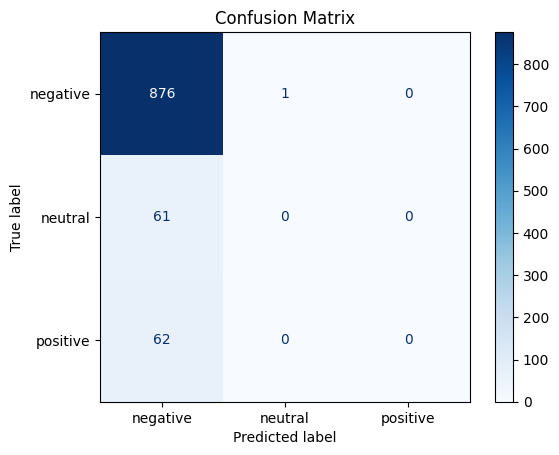


Classification Report:
              precision    recall  f1-score   support

    negative       0.88      1.00      0.93       877
     neutral       0.00      0.00      0.00        61
    positive       0.00      0.00      0.00        62

    accuracy                           0.88      1000
   macro avg       0.29      0.33      0.31      1000
weighted avg       0.77      0.88      0.82      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

predictions = trainer.predict(test_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=1)

true_labels = test_labels.values

cm = confusion_matrix(true_labels, predicted_labels)

target_names = list(label_map.keys())

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

print('\nClassification Report:')
print(classification_report(true_labels, predicted_labels, target_names=target_names))

In [39]:
!pip install wordcloud

In [40]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt

Generating WordCloud...


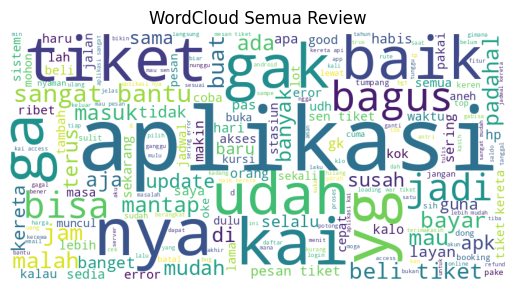

In [41]:
print("Generating WordCloud...")

# Gabungkan semua teks
text_all = " ".join(
    df["clean_review"]
)

# Buat wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text_all)

# Tampilkan
plt.figure()

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud Semua Review")

plt.show()

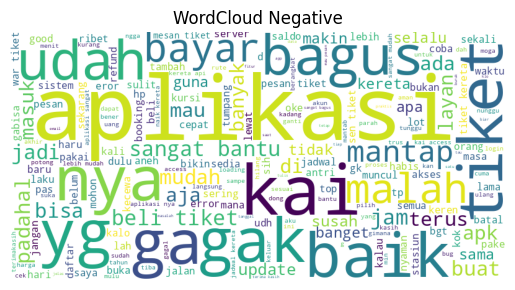

In [42]:
negative_text = " ".join(
    df[df["sentiment"] == "negative"]["clean_review"]
)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure()

plt.imshow(wordcloud_negative)

plt.axis("off")

plt.title("WordCloud Negative")

plt.show()

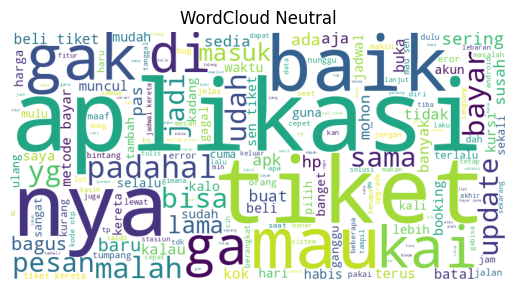

In [43]:
neutral_text = " ".join(
    df[df["sentiment"] == "neutral"]["clean_review"]
)

wordcloud_neutral = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(neutral_text)

plt.figure()

plt.imshow(wordcloud_neutral)

plt.axis("off")

plt.title("WordCloud Neutral")

plt.show()

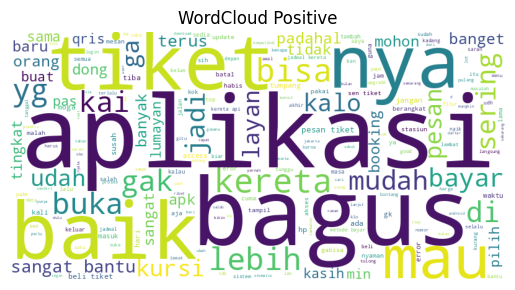

In [44]:
positive_text = " ".join(
    df[df["sentiment"] == "positive"]["clean_review"]
)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure()

plt.imshow(wordcloud_positive)

plt.axis("off")

plt.title("WordCloud Positive")

plt.show()